In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from collections.abc import Callable
from dataclasses import dataclass
from typing import Tuple, Dict

In [2]:
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

plt.rc('font', family='serif', serif="cmr10", size=18)
plt.rc('mathtext', fontset='cm', rm='serif')
plt.rc('axes', unicode_minus=False)

plt.rcParams['axes.formatter.use_mathtext'] = True

In [3]:
@dataclass
class LameConfig:
    x: float; y: float
    theta: float
    a: float; b: float
    m: int = 6
    
    def __post_init__(self) : assert not(self.m%2), '`m` parameter of level set should be even.'

Let $\mathbf{x}_i$ be a point on the boundary of the $i$-th superellipse body. we can express it parametrically, in terms of $t\in[0,2\pi)$, as follows:

$$
\tilde{\mathbf{x}}_i(t) = \begin{pmatrix}
\operatorname{sgn}(\cos t)\cdot|\cos t|^{2/m_i} \\ 
\operatorname{sgn}(\sin t)\cdot|\sin t|^{2/m_i}
\end{pmatrix}.
$$

$$
\mathbf{t}_i = (x_i, y_i)^\intercal
$$

$$
\mathbf{S}_i = \begin{pmatrix}
    a_i/2 & 0 \\ 0 & b_i/2
\end{pmatrix}
$$

$$
\mathbf{x}_i(t) = \mathbf{R}_\text{2D}(\theta_i)\mathbf{S}_i\tilde{\mathbf{x}}_i(t) + \mathbf{t}_i
$$

Then the distance $d_{i\to j}$ between two curves is minimized when

$$
d_{i\to j}^\star \in \min_{t,s} d_{i\to j}(t, s)
$$

$$
d_{i\to j}(t, s) = \| \mathbf{x}_i(t) - \mathbf{x}_j(s) \| \qquad (d_{i\to j}(t,s) = d_{j\to i}(s, t))
$$

I'm not able to solve $\nabla_{(t,s)} d_{i\to j} = \mathbf{0}$ because of all the trig functions involved. Also idk about how many local minima?

Since the landscape of $d_{i\to j}$ is nice you can optimize for $(t^\star, s^\star)$ quite quickly >5ms on my laptop (if you bound the search region for $(t,s)$ to something logical).

In [4]:
def lame_curve(
    t: float, 
    lc: LameConfig
) -> Tuple[float, float] :
    X = np.c_[
        (lc.a/2) * np.sign(np.cos(t)) * np.abs(np.cos(t))**(2/lc.m), 
        (lc.b/2) * np.sign(np.sin(t)) * np.abs(np.sin(t))**(2/lc.m)
    ].T

    R = np.array([
        [np.cos(lc.theta), -np.sin(lc.theta)],
        [np.sin(lc.theta),  np.cos(lc.theta)]
    ])

    return (R @ X).T + (lc.x, lc.y)

def dist(
    ts : Tuple[float, float], 
    lcs: Tuple[LameConfig, LameConfig]
) -> float :
    (t, s), (lc1, lc2) = (ts, lcs)
    return np.hypot(
        *(lame_curve(t, lc1) - lame_curve(s, lc2)).T
    )

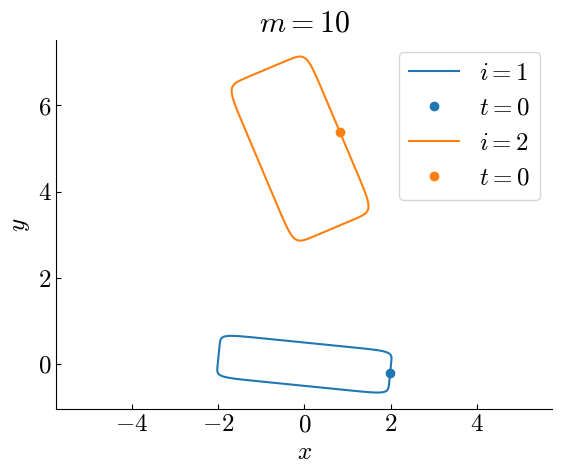

In [5]:
m = 10

lame_configs = (
    LameConfig(0, 0, -.1, 4, 1, m=m),
    LameConfig(-.1, 5, .4, 2, 4, m=m)
)

t = np.linspace(0, 2*np.pi, n := 80)

for (i, lc) in enumerate(lame_configs) : 
    plt.plot(*lame_curve(t, lc).T, label=f'$i={i+1}$')
    plt.plot(*lame_curve(0, lc).T, f'C{i}o', label=f'$t=0$')

plt.axis('equal'); plt.xlabel('$x$'); plt.ylabel('$y$'); plt.title(f'$m={m}$'); plt.legend();

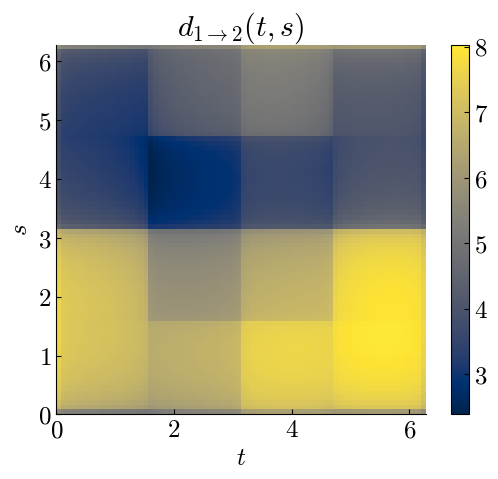

In [6]:
(T, S) = np.meshgrid(t, t[::-1])

plt.colorbar(plt.imshow(
    dist((T.flatten(), S.flatten()), lame_configs).reshape(n, n), 
    extent=(T.min(), T.max(), S.min(), S.max()), cmap='cividis'
))
plt.xlabel('$t$'); plt.ylabel('$s$'); plt.title(r'$d_{1\to2}(t,s)$');

Now to start finding $(t^\star, s^\star)$ we can make an initial guess based on a special and very simple case: circles ($m_k=2$ and $a_k=b_k$). In this case $\mathbf{x}_i(t^\star)$ and $\mathbf{x}_j(s^\star)$ lie on the line connecting the two center points of the circles.

To calcuate $(t,s)$ that correspond to this we can simply calculate the angle between the two center points and correct it with local orientation $\theta_k$ of the shape (see plot below).

$$
\tan \varphi_{i\to j} = \frac{y_j - y_i}{x_j - x_i}
$$

$$
t^\star = \varphi_{i\to j} - \theta_i;\qquad
s^\star = \varphi_{j\to i} - \theta_j.
$$

In [7]:
def guess_minimum(lcs: Tuple[LameConfig, LameConfig]) -> Tuple[float, float]:
    (lc1, lc2) = lcs

    t_est = lambda ls_i, ls_j : (
        np.arctan2(ls_j.y - ls_i.y, ls_j.x - ls_i.x) - ls_i.theta
    ) % (2*np.pi)

    return (t_est(lc1, lc2), t_est(lc2, lc1))

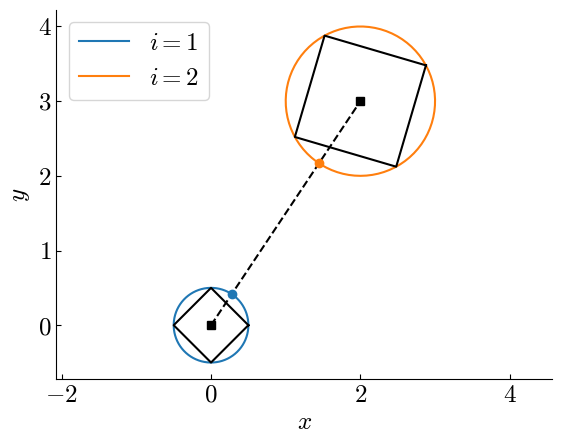

In [8]:
circles = (c1, c2) = (
    LameConfig(0, 0, 0, 1, 1, m=2),
    LameConfig(2, 3, .5, 2, 2, m=2)
)

t_star = guess_minimum(circles)

t_dashed = np.linspace(0, 2*np.pi, 5)
for (i, lc) in enumerate(circles) : 
    plt.plot(*lame_curve(t, lc).T, label=f'$i={i+1}$')
    plt.plot(*lame_curve(t_dashed, lc).T, 'k-')
    plt.plot(*lame_curve(t_star[i], lc).T, f'C{i}o')

plt.plot((c1.x, c2.x), (c1.y, c2.y), 'ks--', zorder=-1)
plt.axis('equal'); plt.xlabel('$x$'); plt.ylabel('$y$'); plt.legend();

To bound the search region we can take the two cosest quadrants of the shape (half of the shape). It's safer than picking a single quadrant bc this quadrant can change based $m$.

In [9]:
def bounds_quadrants(t) :
    center = np.pi/2*(2*(t + np.pi/4)//np.pi)
    return np.c_[center-np.pi/2, center+np.pi/2]

def bounds_simple(t) : return np.c_[t - np.pi/2, t + np.pi/2]

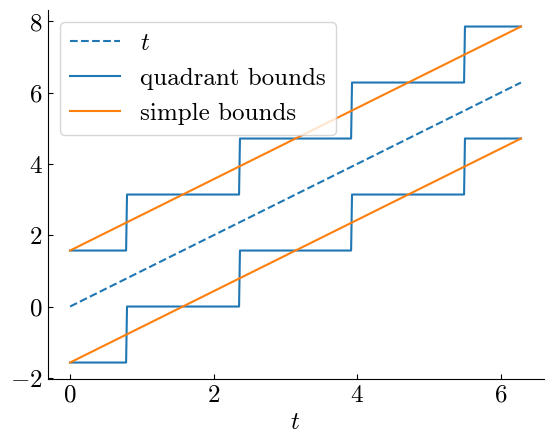

In [10]:
t = np.linspace(0, 2*np.pi, 500)

plt.plot(t, t, 'C0--', label='$t$')
plt.plot(t, bounds_quadrants(t).T[0], c='C0', label='quadrant bounds'); plt.plot(t, bounds_quadrants(t).T[1], c='C0')
plt.plot(t, bounds_simple(t).T[0], c='C1', label='simple bounds'); plt.plot(t, bounds_simple(t).T[1], c='C1')
plt.xlabel('$t$'); plt.legend();

In [11]:
def solve(
    lcs: Tuple[LameConfig, LameConfig],
    bounds_method: Callable=bounds_quadrants,
) -> Dict :
    result = {}
    (result['t_est'], result['s_est']) = guess_minimum(lcs)

    result['bounds'] = (result['bounds_t'], result['bounds_s']) = (
        bounds_method(result['t_est'])[0], 
        bounds_method(result['s_est'])[0]
    )

    result['soln'] = minimize(
        fun=dist,
        x0=(result['t_est'], result['s_est']),
        bounds=result['bounds'],
        args=(lame_configs,),
        method='L-BFGS-B',
    )
    return result

for lc in lame_configs : lc.m = 6
solve(lame_configs)

{'t_est': 1.6907936607680472,
 's_est': 4.332386314357841,
 'bounds': (array([0.        , 3.14159265]), array([3.14159265, 6.28318531])),
 'bounds_t': array([0.        , 3.14159265]),
 'bounds_s': array([3.14159265, 6.28318531]),
 'soln':   message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
   success: True
    status: 0
       fun: 2.406695327622454
         x: [ 1.575e+00  4.282e+00]
       nit: 12
       jac: [-1.465e-06 -8.882e-08]
      nfev: 57
      njev: 19
  hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>}

In [12]:
%%timeit
solve(lame_configs)

2.1 ms ± 126 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Solving the shortest distance between two superellipes with this method takes around ~2ms on my laptop. It is shorter for lower $m$ but the optimizer gets stuck for $m>10$. In the heatmap you can also see the larger the $m$ the more discrete the $d$ function becomes. For $m>10$ you're probably better of with bounding boxes anyways. For these standard methods exist which are widely used in the gaming industry I think. For $m=2$ probably an analytical solution can be derived since you can get rid of these absolute and sign terms, or/and you don't have to partition your function in different domains.

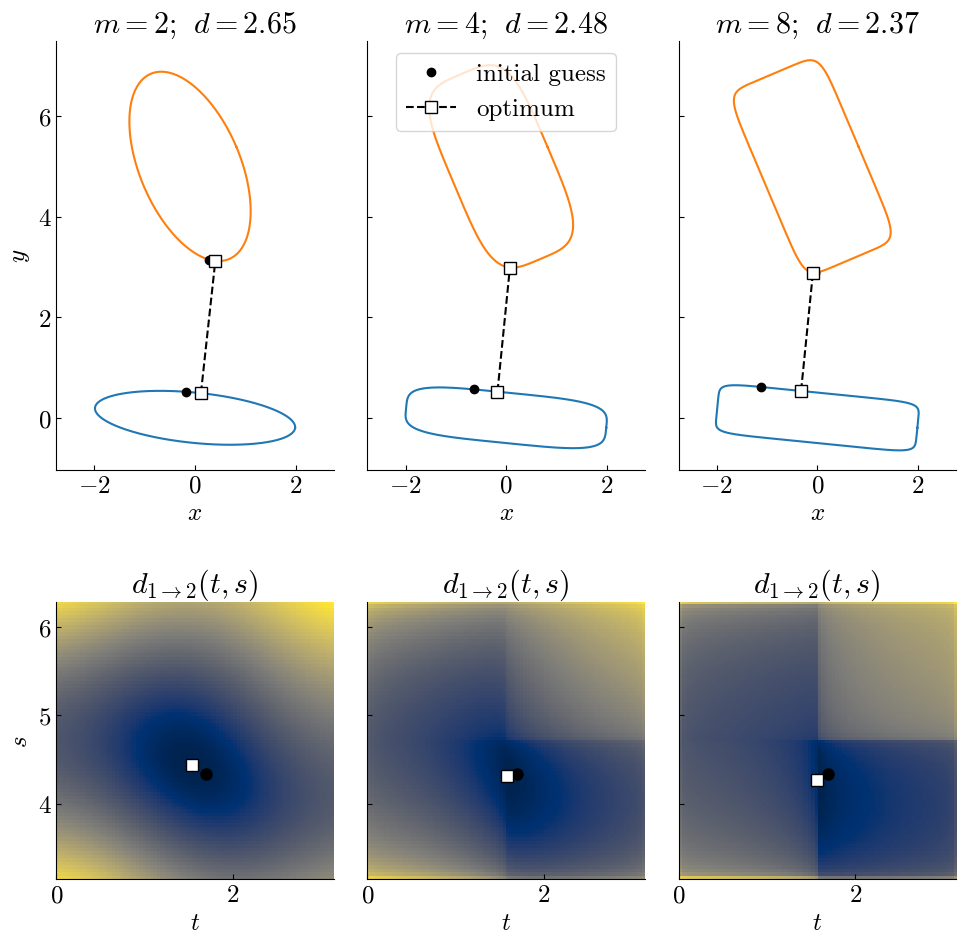

In [13]:
m = (2, 4, 8)

fig, ax = plt.subplots(2, len(m), figsize=(10,10), sharey='row')
for j, mj in enumerate(m):
    for lc in lame_configs : lc.m = mj

    result = solve(lame_configs)
    (bounds_t, bounds_s, t_est, s_est, soln) = (result['bounds_t'], result['bounds_s'], result['t_est'], result['s_est'], result['soln'])

    (T, S) = np.meshgrid(
        np.linspace(*bounds_t, n),
        np.linspace(*bounds_s, n)[::-1]
    )

    d = dist((T.flatten(), S.flatten()), lame_configs).reshape(n, n)
    dmin = result['soln']['fun']
    
    ax[0,j].set_title(fr'$m={mj};\:\:d={dmin:.2f}$')

    for lc in lame_configs : ax[0,j].plot(*lame_curve(t, lc).T)
    ax[0,j].plot(*lame_curve(t_est, lame_configs[0]).T, 'ko', label='initial guess')
    ax[0,j].plot(*lame_curve(s_est, lame_configs[1]).T, 'ko')

    p1 = lame_curve(soln.x[0], lame_configs[0])
    p2 = lame_curve(soln.x[1], lame_configs[1])
    ax[0,j].plot(*np.r_[p1, p2].T, 'ks--', ms=8, mfc='w', label='optimum')

    ax[0,j].set_xlabel('$x$')

    ax[0,j].axis('equal')
    
    ax[1,j].imshow(d, extent=(T.min(), T.max(), S.min(), S.max()), cmap='cividis')
    ax[1,j].plot(t_est, s_est, 'ko', ms=8)
    ax[1,j].plot(*soln.x, 'ks', ms=8, mfc='w')
    ax[1,j].set_xlabel('$t$')
    ax[1,j].set_title(r'$d_{1\to2}(t,s)$')

ax[0,1].legend(loc='upper center')
ax[0,0].set_ylabel('$y$')
ax[1,0].set_ylabel('$s$')

fig.tight_layout()